# EDA & Data Visualisation — Network Intrusion Detection (CIC-IDS2017)

This notebook explores the **CIC-IDS2017** *MachineLearningCVE* CSV files (8 files, 2,830,743 rows, 78 flow features + `Label`) and writes the cleaned checkpoint used by the modelling notebook.

What it does:
1. Merges the 8 day-files into one DataFrame and keeps `source_file` for traceability
2. Cleans column names and the corrupted byte in the `Web Attack` labels
3. Converts `Infinity` to `NaN` and investigates **negative values in every numeric column**; physically impossible negatives become `NaN`, while the documented `-1` sentinel in `Init_Win_bytes_*` is kept
4. Quantifies duplicated rows and label-conflicting feature patterns (reported, not removed)
5. Flags constant and duplicated columns (reported, not removed)
6. Describes class imbalance, capture-day structure and shortcut-prone features that matter for evaluation
7. Uses samples for heavy plots

> **How to run:** place the 8 CSV files in `data/MachineLearningCVE/`, then run all cells **top to bottom in a fresh kernel**. The cleaned checkpoint is written to `data/processed/cic_ids2017_cleaned_v2.parquet` for `02_model_development.ipynb`. Cells are not designed to be re-run out of order (e.g. `Label_binary` is removed in Section 20). Roughly 6 GB of free RAM is needed.
>
> **Outputs for the report:** figures are saved to `results/eda/figures/`, tables to `results/eda/tables/`, and both are collected in `results/eda/report_assets.html` (Section 22) for copy-paste.

## Content List
1. Import libraries
2. Locate & load the 8 CSV files into one DataFrame
3. Clean column names
4. First look: `head`, `shape`, `columns`, `info`
5. Handle infinite values (and pre-existing missing values)
6. Check duplicated rows (and label conflicts)
7. Missing values: counts & percentages
8. Summary statistics with `describe()`
9. Investigate & fix negative values (all numeric columns)
10. Constant and duplicated columns
11. Clean the `Label` values
12. Target (`Label`) balance check — the class imbalance problem
13. Binary view: Benign vs. Attack
14. Build the analysis sample (post-cleaning)
15. Correlation matrix & heatmap
16. Distribution plots for key numeric features
17. Flow Duration by class (boxplots)
18. Attack type breakdown
18b. Capture-day structure and shortcut-prone features
19. Mutual information — feature relevance ranking
20. Final cleaning check
21. Save the cleaned dataset
22. Export tables and figures for the report

## 1. Import libraries

In [4]:
import hashlib
import importlib.metadata
import json
import os
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

## 2. Locate & load the 8 CSV files

Why: the dataset comes as 8 separate CSVs (one per capture day/scenario). We combine them into a single DataFrame so we can analyse the full picture. A `source_file` column is kept so every row can be traced back to the day it was captured.

In [5]:
# Raw CSV files are expected in data/MachineLearningCVE/.
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

data_dir = PROJECT_ROOT / "data" / "MachineLearningCVE"

print("Directory exists:", data_dir.exists())

csv_files = sorted(
    p for p in data_dir.glob("*.csv")
    if "cleaned" not in p.name.lower()
)

print(f"\nFound {len(csv_files)} raw files:")
for f in csv_files:
    print(" -", f.name)

assert len(csv_files) == 8, (
    "Expected the 8 CIC-IDS2017 MachineLearningCVE CSV files."
)

Directory exists: True

Found 8 raw files:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [6]:
# Output folders for report figures and tables.
EDA_RESULTS_DIR = PROJECT_ROOT / "results" / "eda"
FIGURES_DIR = EDA_RESULTS_DIR / "figures"
TABLES_DIR = EDA_RESULTS_DIR / "tables"
for directory in (FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)


def save_figure(name):
    """Save the current figure as a 300-dpi PNG."""
    plt.savefig(FIGURES_DIR / f"{name}.png", dpi=300, bbox_inches="tight")


def save_table(frame, name):
    """Save a table as CSV; a meaningful index is kept as the first column."""
    if isinstance(frame, pd.Series):
        frame = frame.to_frame()
    if not isinstance(frame.index, pd.RangeIndex):
        frame = frame.rename_axis(frame.index.name or "item").reset_index()
    frame.to_csv(TABLES_DIR / f"{name}.csv", index=False)

In [7]:
# Load and concatenate all 8 files
df_list = []
for f in csv_files:
    temp = pd.read_csv(f, low_memory=False)
    temp["source_file"] = f.name          # keep track of which day each row came from
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)
del df_list                                # free memory

print("Combined shape:", df.shape)

Combined shape: (2830743, 80)


## 3. Clean column names

Why: CIC-IDS2017 headers commonly contain leading/trailing spaces (e.g. `' Label'` instead of `'Label'`), which silently breaks column references later.

In [8]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

## 4. First look at the data

Why: `head()`, `shape`, `columns`, and `info()` confirm the data loaded correctly and show data types.

In [9]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [10]:
print("Shape:", df.shape)
df.info(memory_usage="deep")

Shape: (2830743, 80)
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int

## 5. Handle infinite values

Why: flow-rate features (e.g. `Flow Bytes/s`, `Flow Packets/s`) become `Infinity` when a flow's duration is 0. These must be converted to `NaN` before any statistics or ML. The raw files also contain some **empty** cells; they are counted first so the two sources of missing values are not confused.

In [11]:
# Count missing values before replacing infinities.
# Check infinities column-by-column to save memory.

numeric_cols = df.select_dtypes(include=[np.number]).columns
float_cols = df.select_dtypes(include=["float"]).columns

raw_missing = df[numeric_cols].isna().sum()
raw_missing = raw_missing[raw_missing > 0]
print(f"Missing values already present in the raw files: {int(raw_missing.sum()):,}")
display(raw_missing.to_frame("raw_missing_count"))
save_table(raw_missing.to_frame("raw_missing_count"), "table01_raw_missing_values")

inf_count = pd.Series({c: int(np.isinf(df[c].to_numpy()).sum()) for c in float_cols})
inf_count = inf_count[inf_count > 0]

print(f"Infinite values found: {int(inf_count.sum())}")
display(inf_count.to_frame("infinite_count"))
save_table(inf_count.to_frame("infinite_count"), "table02_infinite_values")

for c in inf_count.index:
    df[c] = df[c].replace([np.inf, -np.inf], np.nan)
print("Infinite values remaining:", int(sum(np.isinf(df[c].to_numpy()).sum() for c in float_cols)))

Missing values already present in the raw files: 1,358


,raw_missing_count
Flow Bytes/s,1358


Infinite values found: 4376


,infinite_count
Flow Bytes/s,1509
Flow Packets/s,2867


Infinite values remaining: 0


## 6. Check duplicated rows (and label conflicts)

Why: repeated feature vectors inflate the dataset and, more importantly, can put the same flow pattern into both the training and test sets. We also check whether identical feature vectors ever carry **different** labels, which caps any model's achievable accuracy.

Two definitions are reported:
- **Full-row duplicates** — all 80 columns identical, including `source_file` and `Label`.
- **Feature-level duplicates** — the 78 flow features identical, regardless of file or label. This is the definition relevant to leakage, because the model sees only the features.

In [12]:
# Feature-level duplicates ignore Label and source_file, which is what matters for leakage.
feature_cols = [c for c in df.columns if c not in ["Label", "source_file", "Label_binary"]]

dup_count = df.duplicated().sum()
print(f"Full-row duplicates (excluding first occurrence):     {dup_count:,} "
      f"({dup_count / len(df) * 100:.2f}%)")

feature_dup_mask = df.duplicated(subset=feature_cols)
feature_dup_count = int(feature_dup_mask.sum())
print(f"Feature-level duplicates (excluding first occurrence): {feature_dup_count:,} "
      f"({feature_dup_count / len(df) * 100:.2f}%)")
print(f"  of which differ only in source_file or Label:       {feature_dup_count - dup_count:,}")

duplicate_rows = df[df.duplicated(subset=feature_cols, keep=False)]
print(f"Rows involved in feature-level duplication (all copies): {len(duplicate_rows):,}")

print("\nLabel distribution among feature-level duplicated rows (%):")
duplicated_by_label = duplicate_rows["Label"].value_counts(normalize=True).mul(100).round(3)
display(duplicated_by_label)
save_table(duplicated_by_label.to_frame("pct_of_duplicated_rows"), "table03_duplicated_rows_by_label")

print("\nFeature-level duplicated rows by source file:")
display(duplicate_rows["source_file"].value_counts())

Full-row duplicates (excluding first occurrence):     256,479 (9.06%)
Feature-level duplicates (excluding first occurrence): 309,079 (10.92%)
  of which differ only in source_file or Label:       52,600
Rows involved in feature-level duplication (all copies): 404,558

Label distribution among feature-level duplicated rows (%):


Label
BENIGN                      58.564
PortScan                    25.165
DoS Hulk                    14.730
SSH-Patator                  0.699
FTP-Patator                  0.607
DoS slowloris                0.126
DoS Slowhttptest             0.080
Web Attack � Brute Force     0.015
DDoS                         0.005
Bot                          0.005
DoS GoldenEye                0.003
Name: proportion, dtype: float64


Feature-level duplicated rows by source file:


source_file
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv           115385
Wednesday-workingHours.pcap_ISCX.csv                           106809
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv     55671
Tuesday-WorkingHours.pcap_ISCX.csv                              43699
Monday-WorkingHours.pcap_ISCX.csv                               37085
Friday-WorkingHours-Morning.pcap_ISCX.csv                       19686
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv          17719
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                 8504
Name: count, dtype: int64

In [13]:
# Do identical feature vectors ever carry different labels?
duplicate_feature_rows = duplicate_rows

label_conflicts = (
    duplicate_feature_rows
    .groupby(feature_cols, dropna=False)["Label"]
    .nunique()
)

n_conflicts = int((label_conflicts > 1).sum())
conflict_rows = int(
    duplicate_feature_rows.groupby(feature_cols, dropna=False)["Label"]
    .transform("nunique").gt(1).sum()
)
print("Duplicate feature groups:", f"{len(label_conflicts):,}")
print("Duplicate feature groups with CONFLICTING labels:", f"{n_conflicts:,}")
print("Rows inside conflicting groups:", f"{conflict_rows:,} ({conflict_rows / len(df) * 100:.3f}%)")
save_table(pd.DataFrame({
    "metric": ["Full-row duplicates", "Feature-level duplicates", "Duplicate feature groups",
               "Groups with conflicting labels", "Rows in conflicting groups"],
    "value": [int(dup_count), feature_dup_count, len(label_conflicts), n_conflicts, conflict_rows],
    "pct_of_rows": [dup_count / len(df) * 100, feature_dup_count / len(df) * 100, None, None,
                    conflict_rows / len(df) * 100],
}), "table04_duplicates_summary")
del duplicate_rows, duplicate_feature_rows

Duplicate feature groups: 95,479
Duplicate feature groups with CONFLICTING labels: 698
Rows inside conflicting groups: 7,020 (0.248%)


**Finding.** Feature-level duplication is larger than the full-row count suggests: about **10.9%** of rows repeat an earlier feature vector (**9.06%** when `source_file` and `Label` must also match). About **59%** of the rows involved in feature-level duplication are **BENIGN**; among attacks, **PortScan** (25%) and **DoS Hulk** (15%) dominate. By capture file, the PortScan and Wednesday files contribute the most.

**698** groups of identical feature vectors carry conflicting labels (7,020 rows, about 0.25% of the data). These rows cannot be separated by any model that uses only these features.

Duplicates are **retained in this checkpoint** and must be dealt with **before** the train/test split. The modelling notebook does this by keeping one copy of each pattern and dropping label-conflicting patterns before splitting. Otherwise, repeated patterns land on both sides of the split and inflate test scores.

## 7. Missing values: counts and percentages

In [14]:
def missing_report(frame):
    m = frame.isnull().sum()
    return (pd.DataFrame({"missing_count": m, "missing_pct": m / len(frame) * 100})
              .query("missing_count > 0")
              .sort_values("missing_pct", ascending=False))

MISSING_BEFORE = missing_report(df)
print("Missing values after converting Infinity -> NaN:")
display(MISSING_BEFORE)

Missing values after converting Infinity -> NaN:


,missing_count,missing_pct
Flow Bytes/s,2867,0.101281
Flow Packets/s,2867,0.101281


## 8. Summary statistics

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.0,80.0,443.0,65535.0
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.0,31316.0,3204828.5,119999998.0
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.0,2.0,5.0,219759.0
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.0,2.0,4.0,291922.0
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.0,62.0,187.0,12900000.0
...,...,...,...,...,...,...,...,...
Active Min,2830743.0,5.829582e+04,5.770923e+05,0.0,0.0,0.0,0.0,110000000.0
Idle Mean,2830743.0,8.316037e+06,2.363008e+07,0.0,0.0,0.0,0.0,120000000.0
Idle Std,2830743.0,5.038439e+05,4.602984e+06,0.0,0.0,0.0,0.0,76900000.0
Idle Max,2830743.0,8.695752e+06,2.436689e+07,0.0,0.0,0.0,0.0,120000000.0


## 9. Investigate & fix negative values

Why: durations, rates, inter-arrival times, header lengths and segment sizes cannot be negative. Every numeric column is checked, not only `Flow Duration`, `Flow Bytes/s` and `Flow Packets/s`. The likely cause is a flow-meter timing or overflow artefact; this is not verified here.

One exception is treated as information rather than an error: `Init_Win_bytes_forward` / `Init_Win_bytes_backward` use **`-1`** when no initial TCP window was observed. These are kept as they are and examined in Section 18b.

The investigation and the fix remain in **two separate cells**.

In [16]:
# --- 9a. Investigation only (does not modify df) ---
suspicious_cols = ["Flow Duration", "Flow Bytes/s", "Flow Packets/s"]   # original focus, kept for reference
SENTINEL_COLS = ["Init_Win_bytes_forward", "Init_Win_bytes_backward"]    # -1 = window not observed

neg_counts = {c: int((df[c] < 0).sum()) for c in numeric_cols}
NEG_REPORT = pd.DataFrame([
    {
        "column": c,
        "negative_count": n,
        "negative_pct": n / len(df) * 100,
        "min_value": df[c].min(),
        "distinct_negative_values": int(df.loc[df[c] < 0, c].nunique()),
        "attack_share_of_negatives_pct": (df.loc[df[c] < 0, "Label"] != "BENIGN").mean() * 100,
    }
    for c, n in neg_counts.items() if n > 0
]).set_index("column").sort_values("negative_count", ascending=False)

print(f"Columns containing negative values: {len(NEG_REPORT)}")
display(NEG_REPORT)
save_table(NEG_REPORT, "table05_negative_values")

for c in SENTINEL_COLS:
    negative_values = sorted(df.loc[df[c] < 0, c].unique().tolist())
    print(f"{c}: negative values present = {negative_values}")

negative_mask = (df[suspicious_cols] < 0).any(axis=1)
negative_rows = df.loc[negative_mask]
print("\nRows with a negative Flow Duration / Flow Bytes/s / Flow Packets/s:", f"{len(negative_rows):,}")
print("The same rows in other timing columns (still negative before the fix):")
display((negative_rows[["Flow IAT Mean", "Flow IAT Max", "Flow IAT Min"]] < 0).sum().to_frame("negative_count"))
del negative_rows

Columns containing negative values: 13


,negative_count,negative_pct,min_value,distinct_negative_values,attack_share_of_negatives_pct
column,,,,,
Init_Win_bytes_backward,1441552,50.924863,-1.000000e+00,1,8.502711
Init_Win_bytes_forward,1001189,35.368417,-1.000000e+00,1,0.000699
Flow IAT Min,2891,0.102129,-1.400000e+01,12,6.710481
Flow Duration,115,0.004063,-1.300000e+01,5,0.000000
Flow Packets/s,115,0.004063,-2.000000e+06,5,0.000000
Flow IAT Mean,115,0.004063,-1.300000e+01,5,0.000000
Flow IAT Max,115,0.004063,-1.300000e+01,5,0.000000
Flow Bytes/s,85,0.003003,-2.610000e+08,9,0.000000
Fwd Header Length,35,0.001236,-3.221223e+10,27,0.000000


Init_Win_bytes_forward: negative values present = [-1]
Init_Win_bytes_backward: negative values present = [-1]

Rows with a negative Flow Duration / Flow Bytes/s / Flow Packets/s: 115
The same rows in other timing columns (still negative before the fix):


,negative_count
Flow IAT Mean,115
Flow IAT Max,115
Flow IAT Min,115


In [17]:
# Impossible negative values -> NaN; the -1 sentinel in Init_Win_bytes_* is kept.
# --- 9b. Fix: treat impossible negative values as missing ---
for c in SENTINEL_COLS:
    assert set(df.loc[df[c] < 0, c].unique()) <= {-1}, f"Unexpected negative value in {c}"

IMPOSSIBLE_NEGATIVE_COLS = [c for c in NEG_REPORT.index if c not in SENTINEL_COLS]
print("Columns where negative values are set to NaN:", IMPOSSIBLE_NEGATIVE_COLS)

for c in IMPOSSIBLE_NEGATIVE_COLS:
    df[c] = df[c].mask(df[c] < 0)

print("Negative values remaining outside sentinel columns:",
      int(sum((df[c] < 0).sum() for c in IMPOSSIBLE_NEGATIVE_COLS)))
print("\nMissing values after this step:")
missing_after_cleaning = missing_report(df)
display(missing_after_cleaning)
save_table(missing_after_cleaning, "table06_missing_after_cleaning")

Columns where negative values are set to NaN: ['Flow IAT Min', 'Flow Duration', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Max', 'Flow Bytes/s', 'Fwd Header Length', 'Fwd Header Length.1', 'min_seg_size_forward', 'Bwd Header Length', 'Fwd IAT Min']
Negative values remaining outside sentinel columns: 0

Missing values after this step:


,missing_count,missing_pct
Flow Packets/s,2982,0.105343
Flow Bytes/s,2952,0.104284
Flow IAT Min,2891,0.102129
Flow Duration,115,0.004063
Flow IAT Mean,115,0.004063
Flow IAT Max,115,0.004063
Fwd Header Length,35,0.001236
Fwd Header Length.1,35,0.001236
min_seg_size_forward,35,0.001236
Bwd Header Length,22,0.000777


**Finding.** Negative values occur in 13 numeric columns (see the table above):

- **Timing fields** (`Flow Duration`, `Flow Bytes/s`, `Flow Packets/s`, `Flow IAT Mean/Max/Min`, `Fwd IAT Min`): mostly small values such as `-1` µs. Almost all are BENIGN; `Flow IAT Min` also has a few attack rows.
- **Header/segment sizes** (`Fwd Header Length`, `Fwd Header Length.1`, `Bwd Header Length`, `min_seg_size_forward`): a few dozen rows with huge negative values (down to about −3.2×10¹⁰), consistent with integer overflow.
- **`Init_Win_bytes_forward` / `Init_Win_bytes_backward`**: only the value `-1`, in about 35% and 51% of rows. This is a sentinel, not an error, and is kept.

Impossible values cannot be recovered, so they are set to `NaN` and left un-imputed here. Imputation belongs inside the modelling pipeline, fitted on the training split only. The resulting missing values affect well under 0.2% of rows per column.

## 10. Constant and duplicated columns

Why: several CIC-IDS2017 features are identical for every flow (the *Bulk* counters and the backward PSH/URG flags), and several columns are exact copies of others (for example `Fwd Header Length.1`). They carry no additional information and distort the correlation matrix. We flag them here; the modelling notebook applies its own selection on the training split.

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# --- 10a. Constant (zero-variance) columns ---
nunique = df[num_cols].nunique(dropna=False)
CONSTANT_COLS = nunique[nunique <= 1].index.tolist()

print(f"Constant columns ({len(CONSTANT_COLS)}):")
for c in CONSTANT_COLS:
    print(f"  - {c}  (constant value: {df[c].iloc[0]})")

Constant columns (8):
  - Bwd PSH Flags  (constant value: 0)
  - Bwd URG Flags  (constant value: 0)
  - Fwd Avg Bytes/Bulk  (constant value: 0)
  - Fwd Avg Packets/Bulk  (constant value: 0)
  - Fwd Avg Bulk Rate  (constant value: 0)
  - Bwd Avg Bytes/Bulk  (constant value: 0)
  - Bwd Avg Packets/Bulk  (constant value: 0)
  - Bwd Avg Bulk Rate  (constant value: 0)


In [19]:
# --- 10b. Exactly duplicated columns ---
# Constant columns are excluded here: they are all copies of each other by
# definition, and would flood the output with meaningless pairs.
candidates = [c for c in num_cols if c not in CONSTANT_COLS]

# Hash each column on a 200k-row slice first (cheap), then verify full equality.
probe = df[candidates].head(200_000).fillna(-9_999_999)

buckets = {}
for c in candidates:
    h = int(pd.util.hash_pandas_object(probe[c], index=False).sum())
    buckets.setdefault(h, []).append(c)

DUPLICATE_COLS = []
for cols in buckets.values():
    if len(cols) < 2:
        continue
    keep = cols[0]
    for other in cols[1:]:
        if df[keep].equals(df[other]):
            DUPLICATE_COLS.append((keep, other))

print("Exactly duplicated column pairs:")
for a, b in DUPLICATE_COLS:
    print(f"  - '{b}' is an exact copy of '{a}'")

DROP_CANDIDATES = sorted(set(CONSTANT_COLS) | {b for _, b in DUPLICATE_COLS})
print(f"\nTotal drop candidates for the modelling stage: {len(DROP_CANDIDATES)}")
print(DROP_CANDIDATES)

save_table(pd.DataFrame({"constant_column": CONSTANT_COLS}), "table07_constant_columns")
save_table(pd.DataFrame(DUPLICATE_COLS, columns=["kept_column", "duplicate_column"]), "table08_duplicate_columns")

Exactly duplicated column pairs:
  - 'Subflow Fwd Packets' is an exact copy of 'Total Fwd Packets'
  - 'Subflow Bwd Packets' is an exact copy of 'Total Backward Packets'
  - 'SYN Flag Count' is an exact copy of 'Fwd PSH Flags'
  - 'CWE Flag Count' is an exact copy of 'Fwd URG Flags'
  - 'Fwd Header Length.1' is an exact copy of 'Fwd Header Length'

Total drop candidates for the modelling stage: 13
['Bwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd PSH Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Avg Bulk Rate', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Header Length.1', 'SYN Flag Count', 'Subflow Bwd Packets', 'Subflow Fwd Packets']


**Finding.** 8 constant columns and 5 exactly duplicated column pairs are flagged, **not dropped** — the checkpoint stays faithful to the raw data and feature selection remains an explicit modelling decision. `RST Flag Count` and `ECE Flag Count` correlate at 1.0 in the 50k sample (Section 15) but differ in a handful of rows on the full data, so they are not listed as exact copies.

## 11. Clean the `Label` values

Why: the raw `Thursday-WebAttacks` file was written with a non-UTF-8 byte, so the web-attack labels arrive as `Web Attack � Brute Force`. Left untouched, that corrupted character propagates into the class-distribution chart, the per-class recall table and the slides.

In [20]:
print("Before:", df["Label"].unique().tolist())

df["Label"] = (
    df["Label"]
    .str.replace(r"[^\x00-\x7F]+", "-", regex=True)   # corrupted byte -> hyphen
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print("\nAfter:", df["Label"].unique().tolist())

Before: ['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration', 'Web Attack � Brute Force', 'Web Attack � XSS', 'Web Attack � Sql Injection', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed']

After: ['BENIGN', 'DDoS', 'PortScan', 'Bot', 'Infiltration', 'Web Attack - Brute Force', 'Web Attack - XSS', 'Web Attack - Sql Injection', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris', 'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed']


## 12. Target (`Label`) balance check — the class imbalance problem

Why: this is the central challenge of the project. Most rows are `BENIGN`, while attack types make up a small minority — this plot is the evidence for the "Industry Context / Problem" slide.

,count,percent
Label,,
BENIGN,2273097,80.300
DoS Hulk,231073,8.163
PortScan,158930,5.614
DDoS,128027,4.523
DoS GoldenEye,10293,0.364
FTP-Patator,7938,0.280
SSH-Patator,5897,0.208
DoS slowloris,5796,0.205
DoS Slowhttptest,5499,0.194


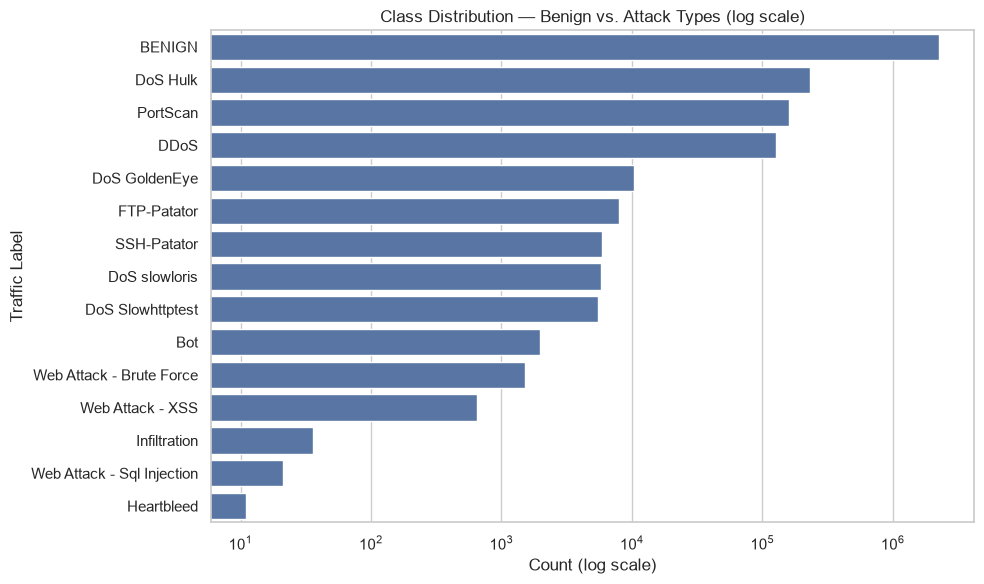

Imbalance ratio (largest : smallest class) = 206,645 : 1


In [21]:
label_counts = df["Label"].value_counts()
label_pct = df["Label"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": label_counts, "percent": label_pct.round(3)})
display(summary)
save_table(summary, "table09_class_distribution")

plt.figure(figsize=(10, 6))
sns.barplot(x=label_counts.values, y=label_counts.index, orient="h")
plt.xscale("log")
plt.xlabel("Count (log scale)")
plt.ylabel("Traffic Label")
plt.title("Class Distribution — Benign vs. Attack Types (log scale)")
plt.tight_layout()
save_figure("figure01_class_distribution")
plt.show()

print(f"Imbalance ratio (largest : smallest class) = "
      f"{label_counts.max() / label_counts.min():,.0f} : 1")

## 13. Binary view: Benign vs. Attack

Why: collapsing all attack types into one "Attack" class gives a clean headline imbalance number for the presentation.

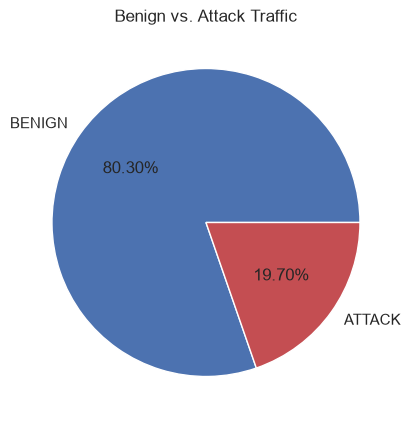

,count
Label_binary,
BENIGN,2273097
ATTACK,557646


In [22]:
df["Label_binary"] = np.where(df["Label"] == "BENIGN", "BENIGN", "ATTACK")
binary_counts = df["Label_binary"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(binary_counts, labels=binary_counts.index, autopct="%1.2f%%",
        colors=["#4C72B0", "#C44E52"])
plt.title("Benign vs. Attack Traffic")
save_figure("figure02_benign_vs_attack")
plt.show()

display(binary_counts.to_frame("count"))
save_table(binary_counts.to_frame("count"), "table10_binary_distribution")

## 14. Build the analysis sample (post-cleaning)

Why: the heavier plots below (heatmap, histograms, boxplots) run on a random sample of 50,000 rows to keep memory and rendering time manageable.

**Important:** the sample is drawn *after* the negative values and labels have been fixed, so the plots reflect the cleaned data.

In [23]:
SAMPLE_SIZE = 50_000
sample_df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_STATE)

print("Sample shape:", sample_df.shape)
print("Sample class balance (%):")
display(sample_df["Label_binary"].value_counts(normalize=True).mul(100).round(2))

print("Negative values in sample (cleaned columns):",
      int((sample_df[IMPOSSIBLE_NEGATIVE_COLS] < 0).sum().sum()))

Sample shape: (50000, 81)
Sample class balance (%):


Label_binary
BENIGN    80.39
ATTACK    19.61
Name: proportion, dtype: float64

Negative values in sample (cleaned columns): 0


## 15. Correlation matrix & heatmap

Why: with 78 numeric features we look for highly correlated / redundant feature pairs to consider dropping before modelling.

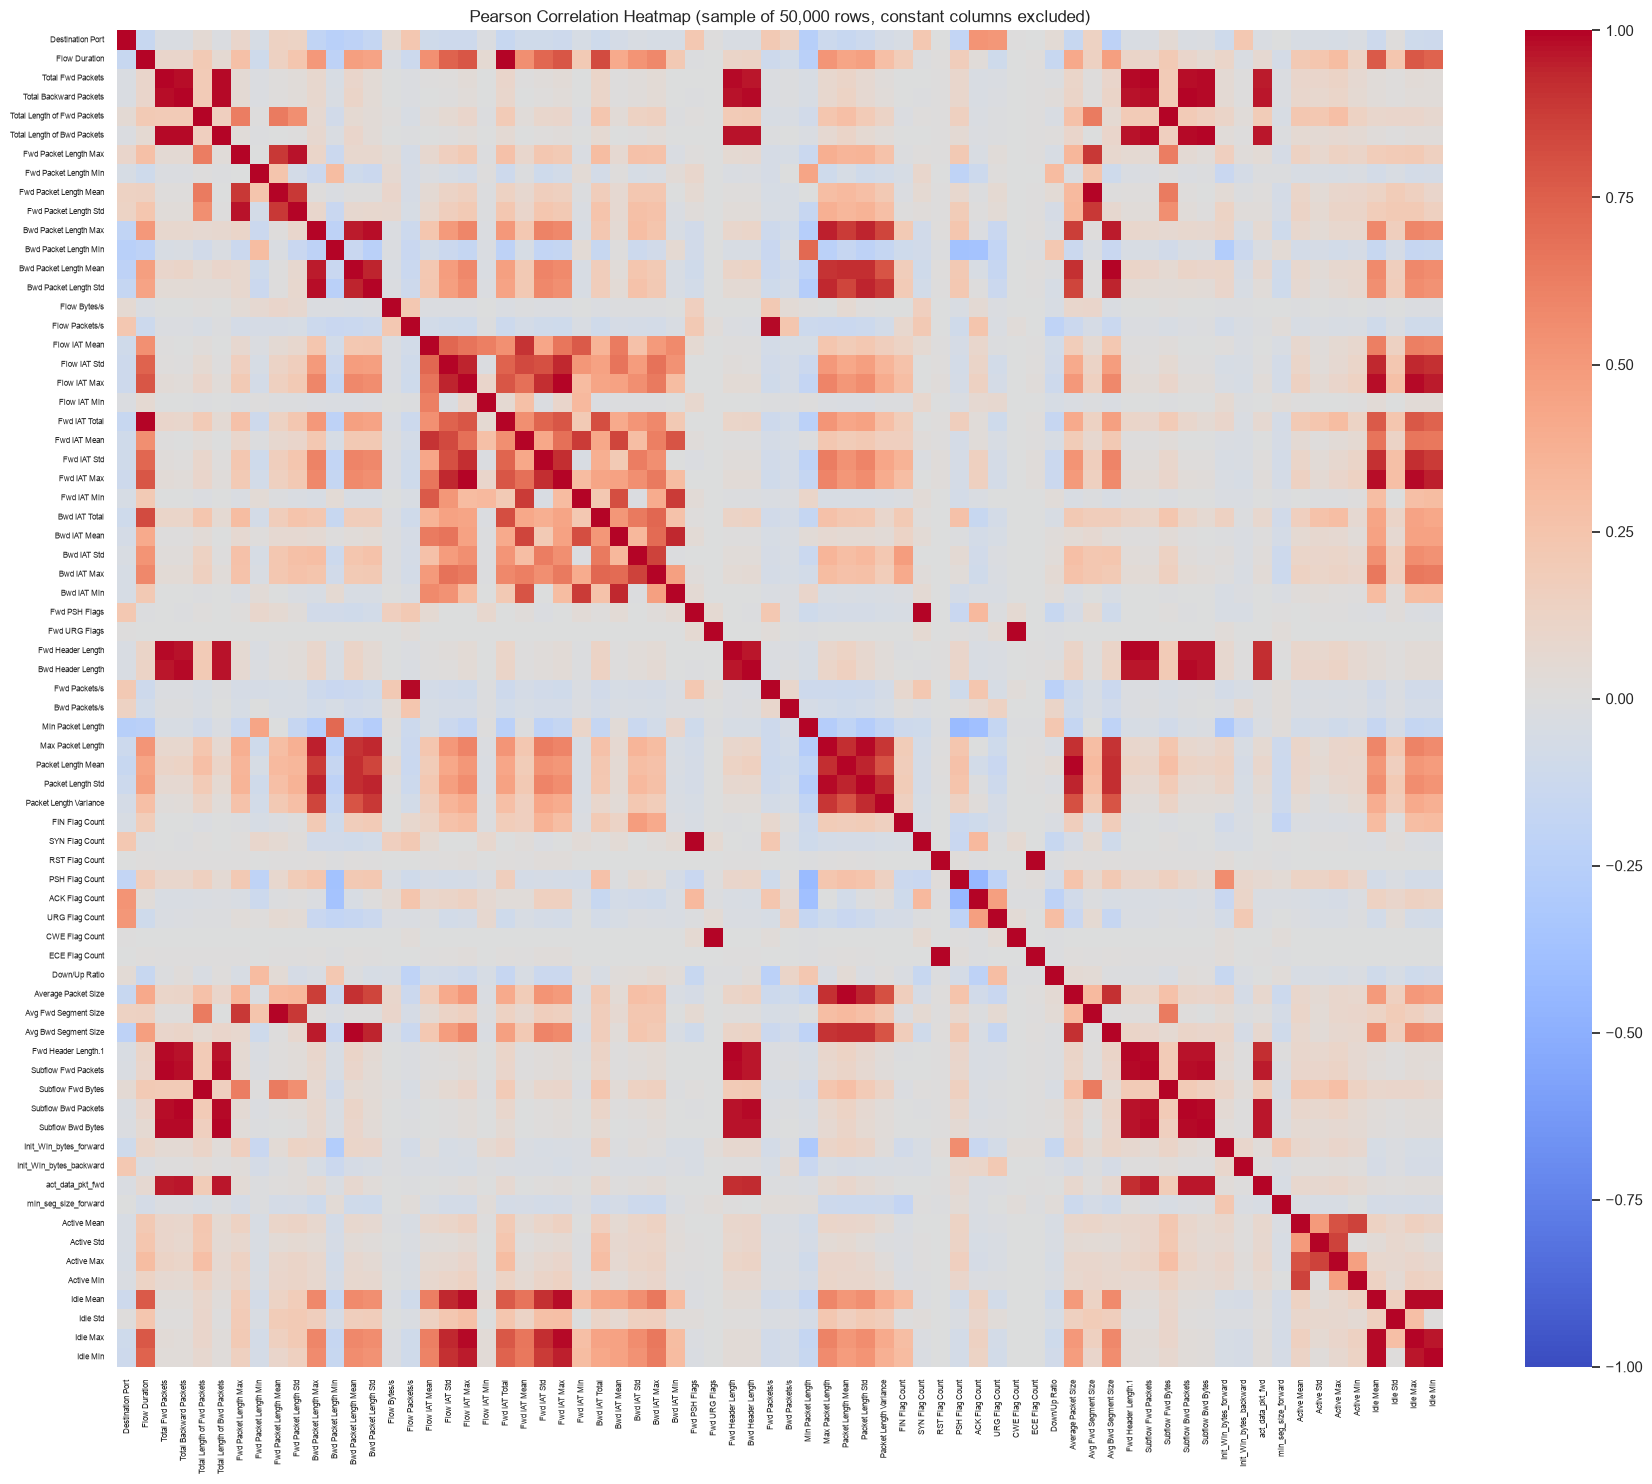

In [24]:
# Constant columns are excluded (their correlation is undefined).
corr_cols = [c for c in num_cols if c not in CONSTANT_COLS]
corr = sample_df[corr_cols].corr()

plt.figure(figsize=(18, 15))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True)
plt.xticks(fontsize=6)
plt.yticks(fontsize=6)
plt.title(f"Pearson Correlation Heatmap (sample of {len(sample_df):,} rows, constant columns excluded)")
plt.tight_layout()
save_figure("figure03_correlation_heatmap")
plt.show()

In [25]:
# Strongest feature correlations — upper triangle only, no double counting
upper = np.triu(np.ones(corr.shape), k=1).astype(bool)

corr_pairs = (
    corr.where(upper)
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

print("Top 30 strongest feature correlations:")
display(corr_pairs.sort_values("abs_correlation", ascending=False).head(30))

Top 30 strongest feature correlations:


,feature_1,feature_2,correlation,abs_correlation
335,Total Length of Fwd Packets,Subflow Fwd Bytes,1.000000,1.000000
611,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,1.000000
2293,Fwd Header Length,Fwd Header Length.1,1.000000,1.000000
2217,Fwd URG Flags,CWE Flag Count,1.000000,1.000000
2142,Fwd PSH Flags,SYN Flag Count,1.000000,1.000000
194,Total Fwd Packets,Subflow Fwd Packets,1.000000,1.000000
3058,RST Flag Count,ECE Flag Count,1.000000,1.000000
266,Total Backward Packets,Subflow Bwd Packets,1.000000,1.000000
892,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,1.000000
407,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000,1.000000


In [26]:
# Flag highly correlated pairs (potential redundancy)
THRESHOLD = 0.9

high_corr_df = (
    corr_pairs.loc[corr_pairs["abs_correlation"] > THRESHOLD]
              .sort_values("abs_correlation", ascending=False)
              .reset_index(drop=True)
)

perfect = high_corr_df.loc[high_corr_df["abs_correlation"] >= 0.999]

print(f"Feature pairs with |correlation| > {THRESHOLD}: {len(high_corr_df)}")
print(f"Of which effectively perfect (>= 0.999): {len(perfect)}")
display(perfect)
save_table(high_corr_df, "table11_high_correlation_pairs")

Feature pairs with |correlation| > 0.9: 99
Of which effectively perfect (>= 0.999): 10


,feature_1,feature_2,correlation,abs_correlation
0,Fwd Packet Length Mean,Avg Fwd Segment Size,1.0,1.0
1,Fwd URG Flags,CWE Flag Count,1.0,1.0
2,Fwd PSH Flags,SYN Flag Count,1.0,1.0
3,Fwd Header Length,Fwd Header Length.1,1.0,1.0
4,Total Fwd Packets,Subflow Fwd Packets,1.0,1.0
5,Total Backward Packets,Subflow Bwd Packets,1.0,1.0
6,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0,1.0
7,Total Length of Fwd Packets,Subflow Fwd Bytes,1.0,1.0
8,RST Flag Count,ECE Flag Count,1.0,1.0
9,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0,1.0


**Finding.** **99** feature pairs exceed |r| > 0.9 in the sample, and **10** pairs are effectively perfect (≥ 0.999). Examples include `Total Fwd Packets` / `Subflow Fwd Packets` and `Fwd Packet Length Mean` / `Avg Fwd Segment Size`.

These are Pearson correlations on raw, heavy-tailed values, so a few extreme flows can drive them. They are computed on data that will later include the test set, so they are **descriptive only**. Any redundancy filter used for modelling must be refitted on the training split, as the modelling notebook does.

Redundancy matters most for the linear baseline (multicollinearity makes Logistic Regression coefficients unstable) and for the Autoencoder (redundant inputs are counted several times in the reconstruction error). It matters much less for tree-based models.

## 16. Distribution plots for key numeric features

Why: understand the shape and skew of the most important flow features. A handful of well-chosen features is more readable than all 78.

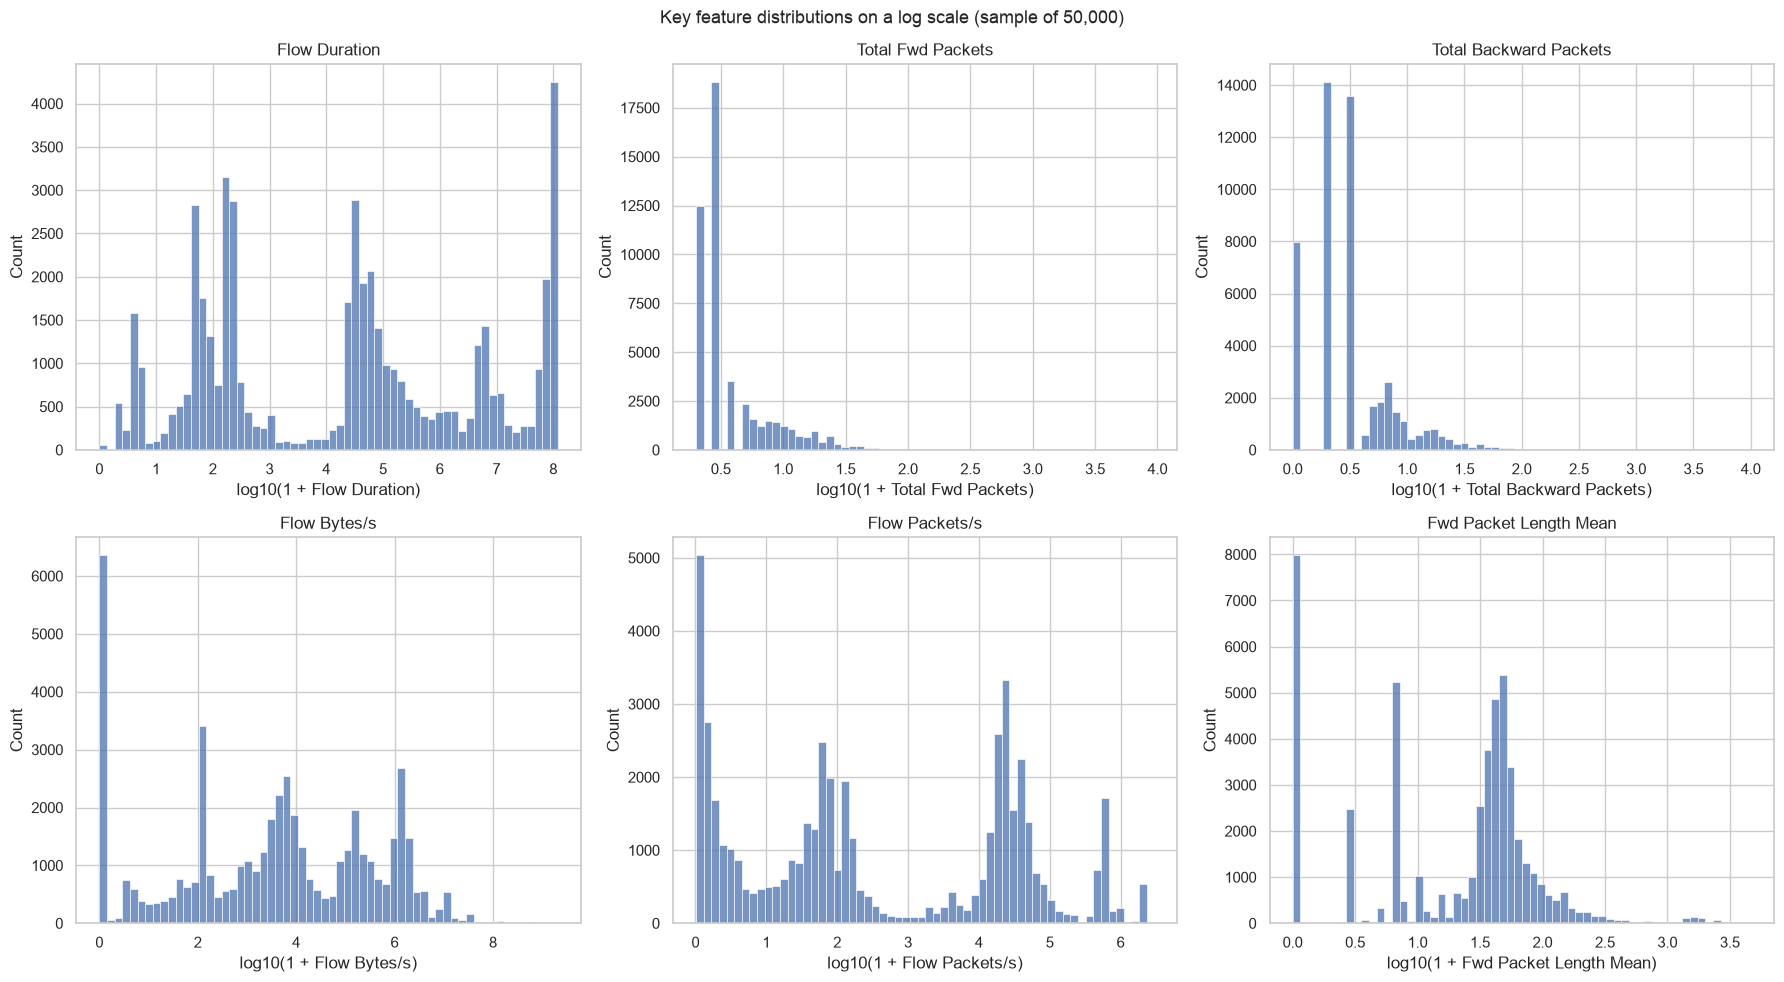

Distribution summary (raw values):


,skewness,min,median,95th_percentile,99th_percentile,max
Total Fwd Packets,104.807854,1.000000,2.000000,1.900000e+01,5.000000e+01,9.449000e+03
Total Backward Packets,97.728265,0.000000,2.000000,1.700000e+01,5.800000e+01,1.006300e+04
Flow Bytes/s,49.693305,0.000000,4610.381404,2.261171e+06,1.233333e+07,2.070000e+09
Fwd Packet Length Mean,9.267452,0.000000,34.000000,1.430029e+02,1.035500e+03,4.672000e+03
Flow Packets/s,5.525077,0.016963,113.915399,6.666667e+05,2.000000e+06,3.000000e+06
Flow Duration,2.169184,0.000000,31288.000000,1.011627e+08,1.178150e+08,1.199994e+08


In [27]:
# log10(1 + x) scale: the raw values span several orders of magnitude.
key_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
]
key_features = [c for c in key_features if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flatten(), key_features):
    values = sample_df[col].dropna()
    sns.histplot(np.log10(values + 1), bins=60, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(f"log10(1 + {col})")
plt.suptitle(f"Key feature distributions on a log scale (sample of {len(sample_df):,})", fontsize=13)
plt.tight_layout()
save_figure("figure04_key_feature_distributions")
plt.show()

distribution_summary = pd.DataFrame({
    "skewness":        sample_df[key_features].skew(),
    "min":             sample_df[key_features].min(),
    "median":          sample_df[key_features].median(),
    "95th_percentile": sample_df[key_features].quantile(0.95),
    "99th_percentile": sample_df[key_features].quantile(0.99),
    "max":             sample_df[key_features].max(),
})

print("Distribution summary (raw values):")
display(distribution_summary.sort_values("skewness", ascending=False))
save_table(distribution_summary.sort_values("skewness", ascending=False).rename_axis("feature"), "table12_distribution_summary")

**Finding.** All key features are right-skewed with long tails spanning several orders of magnitude. Packet counts and `Flow Bytes/s` are extreme (skewness about 50–100); `Flow Duration` is only moderately skewed (about 2) but multimodal, with a cluster near the 120 s flow timeout. On a log scale, several features show distinct modes rather than a single shape.

Because of these long tails, a rank- or quantile-based transform is preferable to plain `StandardScaler` for the **scale-sensitive** models: Logistic Regression and the Autoencoder. Tree models are unaffected.

## 17. Flow Duration by class (boxplots)

Why: compare the spread of a key feature between BENIGN and ATTACK traffic. Outliers are not shown; the table below gives quartiles and extremes. `Flow Duration` is in microseconds (CICFlowMeter convention; the maximum of about 1.2×10⁸ µs matches its 120 s flow timeout).

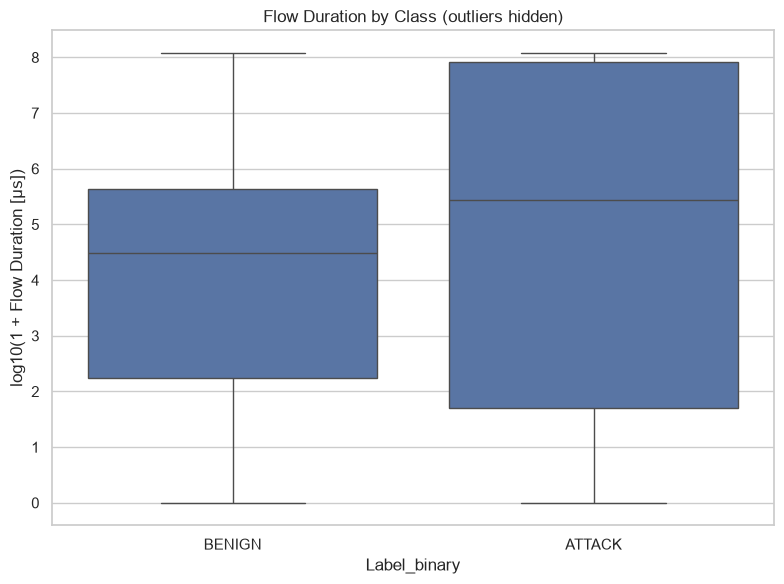

,count,min,Q1,median,Q3,max,IQR
Label_binary,,,,,,,
ATTACK,9807,0.0,49.0,272843.0,84007264.5,118353342.0,84007215.5
BENIGN,40190,0.0,173.0,31011.0,433627.5,119999443.0,433454.5


In [28]:
# Log scale so both classes are readable.
plt.figure(figsize=(8, 6))
plot_frame = sample_df[["Label_binary", "Flow Duration"]].dropna().assign(
    log_duration=lambda d: np.log10(d["Flow Duration"] + 1)
)
sns.boxplot(data=plot_frame, x="Label_binary", y="log_duration", showfliers=False)
plt.ylabel("log10(1 + Flow Duration [µs])")
plt.title("Flow Duration by Class (outliers hidden)")
plt.tight_layout()
save_figure("figure05_flow_duration_by_class")
plt.show()

boxplot_summary = (
    sample_df.groupby("Label_binary")["Flow Duration"]
    .agg(count="count", min="min",
         Q1=lambda x: x.quantile(0.25),
         median="median",
         Q3=lambda x: x.quantile(0.75),
         max="max")
)
boxplot_summary["IQR"] = boxplot_summary["Q3"] - boxplot_summary["Q1"]
display(boxplot_summary)
save_table(boxplot_summary, "table13_flow_duration_by_class")

## 18. Attack type breakdown

Why: shows exactly which attack categories are present and how rare each one is — directly supports the "Data Sources and Data Availability" slide.

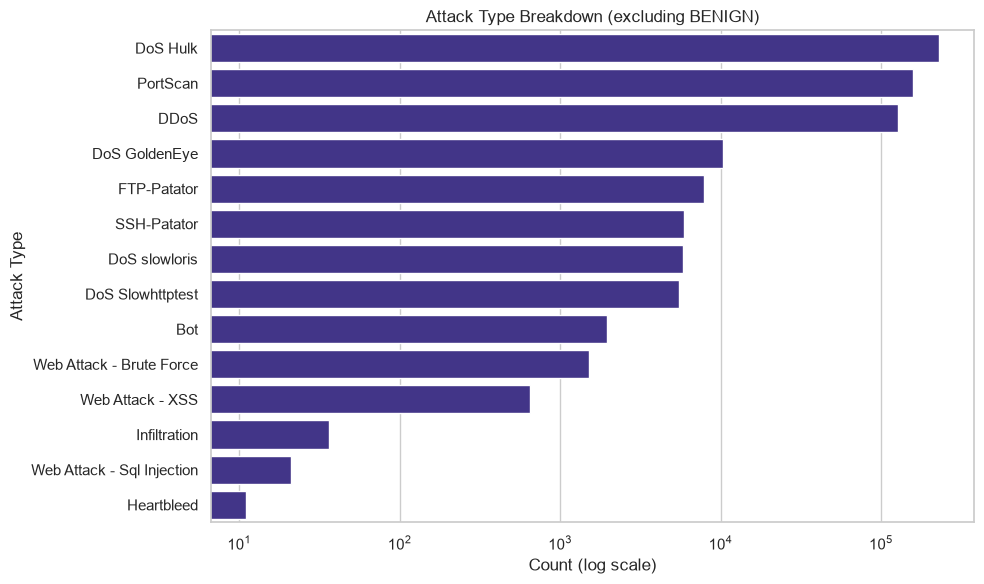

Attack type distribution:


,count,pct_of_attacks,pct_of_dataset
Label,,,
DoS Hulk,231073,41.437,8.1630
PortScan,158930,28.500,5.6144
DDoS,128027,22.958,4.5227
DoS GoldenEye,10293,1.846,0.3636
FTP-Patator,7938,1.423,0.2804
SSH-Patator,5897,1.057,0.2083
DoS slowloris,5796,1.039,0.2048
DoS Slowhttptest,5499,0.986,0.1943
Bot,1966,0.353,0.0695


In [29]:
attack_only = df.loc[df["Label"] != "BENIGN", "Label"].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=attack_only.values, y=attack_only.index, orient="h", color="#382796")
plt.xscale("log")
plt.xlabel("Count (log scale)")
plt.ylabel("Attack Type")
plt.title("Attack Type Breakdown (excluding BENIGN)")
plt.tight_layout()
save_figure("figure06_attack_type_breakdown")
plt.show()

attack_summary = pd.DataFrame({
    "count": attack_only,
    "pct_of_attacks": (attack_only / attack_only.sum() * 100).round(3),
    "pct_of_dataset": (attack_only / len(df) * 100).round(4),
})
print("Attack type distribution:")
display(attack_summary)
save_table(attack_summary, "table14_attack_types")

**Finding.** Three attacks (DoS Hulk, PortScan, DDoS) account for ~93% of all malicious traffic, while `Heartbleed` (11 rows), `Sql Injection` (21) and `Infiltration` (36) are so rare that no per-class metric on them will be statistically meaningful. This is exactly why the project is framed as **binary** detection with a **per-attack-type recall breakdown** as a secondary diagnostic, rather than as 15-class classification.

## 18b. Capture-day structure and shortcut-prone features

Why: a model can reach high scores by learning *where* or *how* a flow was captured rather than whether it is malicious. Three quick checks:

1. **Label × capture file:** does each attack family come from a single day?
2. **Destination port per attack family:** do attacks use a single port?
3. **`Init_Win_bytes_*` = -1 by class:** does the sentinel separate the classes?

In [30]:
# Label x capture file, dominant port per attack family, and the Init_Win sentinel by class.
day_short = df["source_file"].str.replace(".pcap_ISCX.csv", "", regex=False)
label_by_file = pd.crosstab(df["Label"], day_short)
print("Rows per label and capture file:")
display(label_by_file)
save_table(label_by_file, "table15_label_by_capture_file")
files_per_family = (label_by_file.drop(index="BENIGN") > 0).sum(axis=1)
print("Capture files containing each attack family:", files_per_family.to_dict())

attack_rows = df["Label"] != "BENIGN"
port_share = (
    df.loc[attack_rows].groupby("Label")["Destination Port"]
    .agg(top_port=lambda s: s.value_counts().index[0],
         top_port_share_pct=lambda s: s.value_counts(normalize=True).iloc[0] * 100,
         distinct_ports="nunique")
    .sort_values("top_port_share_pct", ascending=False)
)
print("\nDominant destination port per attack family:")
display(port_share.round(2))
save_table(port_share.round(2), "table16_top_port_per_attack")
print("BENIGN top ports (%):",
      df.loc[~attack_rows, "Destination Port"].value_counts(normalize=True).head(5).mul(100).round(1).to_dict())

sentinel_share = pd.DataFrame({
    c: df.groupby(df["Label_binary"])[c].apply(lambda s: (s == -1).mean() * 100)
    for c in SENTINEL_COLS
}).round(2)
print("\nShare of rows with Init_Win_bytes = -1 (%):")
display(sentinel_share)
save_table(sentinel_share, "table17_init_win_sentinel_share")
del day_short, attack_rows

Rows per label and capture file:


source_file,Friday-WorkingHours-Afternoon-DDos,Friday-WorkingHours-Afternoon-PortScan,Friday-WorkingHours-Morning,Monday-WorkingHours,Thursday-WorkingHours-Afternoon-Infilteration,Thursday-WorkingHours-Morning-WebAttacks,Tuesday-WorkingHours,Wednesday-workingHours
Label,,,,,,,,
BENIGN,97718,127537,189067,529918,288566,168186,432074,440031
Bot,0,0,1966,0,0,0,0,0
DDoS,128027,0,0,0,0,0,0,0
DoS GoldenEye,0,0,0,0,0,0,0,10293
DoS Hulk,0,0,0,0,0,0,0,231073
DoS Slowhttptest,0,0,0,0,0,0,0,5499
DoS slowloris,0,0,0,0,0,0,0,5796
FTP-Patator,0,0,0,0,0,0,7938,0
Heartbleed,0,0,0,0,0,0,0,11


Capture files containing each attack family: {'Bot': 1, 'DDoS': 1, 'DoS GoldenEye': 1, 'DoS Hulk': 1, 'DoS Slowhttptest': 1, 'DoS slowloris': 1, 'FTP-Patator': 1, 'Heartbleed': 1, 'Infiltration': 1, 'PortScan': 1, 'SSH-Patator': 1, 'Web Attack - Brute Force': 1, 'Web Attack - Sql Injection': 1, 'Web Attack - XSS': 1}

Dominant destination port per attack family:


,top_port,top_port_share_pct,distinct_ports
Label,,,
DoS GoldenEye,80,100.00,1
DoS Hulk,80,100.00,1
DoS Slowhttptest,80,100.00,1
DoS slowloris,80,100.00,1
Heartbleed,444,100.00,1
Infiltration,444,100.00,1
SSH-Patator,22,100.00,1
Web Attack - Brute Force,80,100.00,1
Web Attack - Sql Injection,80,100.00,1


BENIGN top ports (%): {53: 42.1, 443: 22.2, 80: 10.4, 123: 1.1, 22: 0.5}

Share of rows with Init_Win_bytes = -1 (%):


,Init_Win_bytes_forward,Init_Win_bytes_backward
Label_binary,,
ATTACK,0.00,21.98
BENIGN,44.04,58.03


**Finding.**
- **Every attack family appears in exactly one capture file**, and Monday contains only BENIGN traffic. `source_file` therefore almost identifies the attack type and must never be a feature (the modelling notebook drops it). It also means a split by day cannot test every family: holding out a day holds out its attack families completely.
- **Most attack families target a single destination port** (for example 80 for the DoS/DDoS and web attacks, 21 for FTP-Patator, 22 for SSH-Patator, 444 for Heartbleed/Infiltration). PortScan is the main exception, and Bot is split across ports (8080 for about 64%). BENIGN traffic is dominated by ports 53, 443 and 80. `Destination Port` is therefore a strong **shortcut** feature: it works inside this dataset but may not transfer to other networks.
- **`Init_Win_bytes_forward = -1` occurs in about 44% of BENIGN rows and almost no attack rows.** Most of these are DNS (port 53) flows, so the sentinel works as a protocol indicator.

These are properties of the capture, not necessarily of malicious behaviour. High scores from a random split should be read with them in mind.

## 19. Mutual information — feature relevance ranking

Why: correlation measures *linear* association between features. Mutual information estimates how much a feature tells us about the **target**, including non-linear relationships.

Caveats: it runs on a 20k stratified sample of the **whole** dataset (future test rows included) with median-imputed values, so it is **descriptive only** and must not drive feature selection. `Destination Port` is treated as a number although it is categorical. Duplicated flows are included.

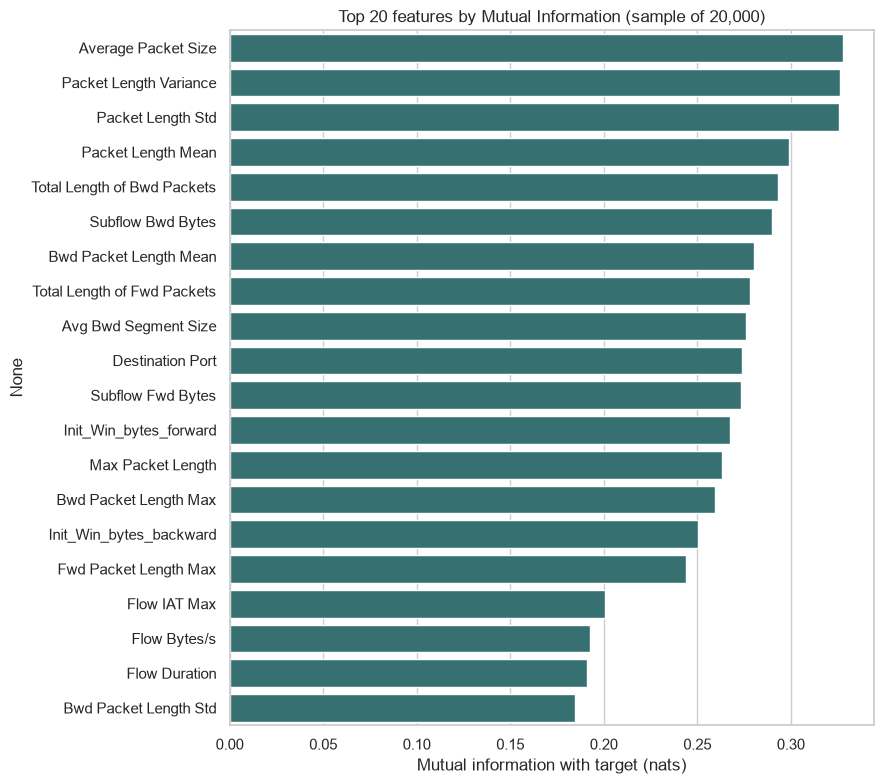

,mutual_information
Average Packet Size,0.328026
Packet Length Variance,0.326223
Packet Length Std,0.325752
Packet Length Mean,0.298735
Total Length of Bwd Packets,0.293004
Subflow Bwd Bytes,0.289906
Bwd Packet Length Mean,0.280333
Total Length of Fwd Packets,0.277942
Avg Bwd Segment Size,0.276069
Destination Port,0.273660


In [31]:
# Sample row positions (not the full DataFrame) to keep memory low.
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

MI_SAMPLE = 20_000

mi_positions, _ = train_test_split(
    np.arange(len(df)), train_size=MI_SAMPLE, random_state=RANDOM_STATE, stratify=df["Label_binary"]
)
mi_sample = df.iloc[mi_positions]

mi_features = [c for c in num_cols if c not in DROP_CANDIDATES]
X_mi = mi_sample[mi_features].fillna(mi_sample[mi_features].median())
y_mi = (mi_sample["Label_binary"] == "ATTACK").astype(int)

mi_scores = pd.Series(
    mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE),
    index=mi_features,
).sort_values(ascending=False)

top_n = mi_scores.head(20)

plt.figure(figsize=(9, 8))
sns.barplot(x=top_n.values, y=top_n.index, orient="h", color="#2C7A7B")
plt.xlabel("Mutual information with target (nats)")
plt.title(f"Top 20 features by Mutual Information (sample of {MI_SAMPLE:,})")
plt.tight_layout()
save_figure("figure07_mutual_information_top20")
plt.show()

display(mi_scores.head(20).to_frame("mutual_information"))
save_table(mi_scores.head(20).to_frame("mutual_information").rename_axis("feature"), "table18_mutual_information_top20")

## 20. Final cleaning check

In [32]:
print("=" * 55)
print("FINAL CLEANING CHECK")
print("=" * 55)

# 1. No impossible negative values remain
print("\n1. Negative values in cleaned columns:")
for col in IMPOSSIBLE_NEGATIVE_COLS:
    print(f"   {col}: {(df[col] < 0).sum()}")
for col in SENTINEL_COLS:
    print(f"   {col}: {(df[col] < 0).sum():,} (documented -1 sentinel, kept)")

# 2. No infinite values remain
print("\n2. Infinite values:",
      int(sum(np.isinf(df[c].to_numpy()).sum() for c in df.select_dtypes(include=["float"]).columns)))

# 3. Remaining missing values (left for the modelling pipeline on purpose)
print("\n3. Missing values (kept, imputed later inside the pipeline):")
display(missing_report(df))

# 4. Label values are clean ASCII
print("\n4. Labels:", df["Label"].nunique(), "classes")
print("   Non-ASCII characters in labels:",
      int(df["Label"].str.contains(r"[^\x00-\x7F]", regex=True).sum()))

# 5. Drop the EDA-only helper column
df.drop(columns=["Label_binary"], inplace=True, errors="ignore")

# 6. Final structure
print("\n5. Final dataset:")
print("   Shape:", df.shape)
print("   'Label' present:", "Label" in df.columns)
print("   'source_file' present:", "source_file" in df.columns)
print("   Columns flagged for dropping at modelling time:", len(DROP_CANDIDATES))

FINAL CLEANING CHECK

1. Negative values in cleaned columns:
   Flow IAT Min: 0
   Flow Duration: 0
   Flow Packets/s: 0
   Flow IAT Mean: 0
   Flow IAT Max: 0
   Flow Bytes/s: 0
   Fwd Header Length: 0
   Fwd Header Length.1: 0
   min_seg_size_forward: 0
   Bwd Header Length: 0
   Fwd IAT Min: 0
   Init_Win_bytes_forward: 1,001,189 (documented -1 sentinel, kept)
   Init_Win_bytes_backward: 1,441,552 (documented -1 sentinel, kept)

2. Infinite values: 0

3. Missing values (kept, imputed later inside the pipeline):


,missing_count,missing_pct
Flow Packets/s,2982,0.105343
Flow Bytes/s,2952,0.104284
Flow IAT Min,2891,0.102129
Flow Duration,115,0.004063
Flow IAT Mean,115,0.004063
Flow IAT Max,115,0.004063
Fwd Header Length,35,0.001236
Fwd Header Length.1,35,0.001236
min_seg_size_forward,35,0.001236
Bwd Header Length,22,0.000777



4. Labels: 15 classes
   Non-ASCII characters in labels: 0

5. Final dataset:
   Shape: (2830743, 80)
   'Label' present: True
   'source_file' present: True
   Columns flagged for dropping at modelling time: 13


### Final Cleaning Check — summary

- **Infinite values** (4,376) were converted to `NaN`; 1,358 `Flow Bytes/s` values were already empty in the raw files.
- **Impossible negative values** were set to `NaN` in every affected column except `Init_Win_bytes_*`, whose `-1` sentinel is kept.
- **Missing values** are deliberately left un-imputed (well under 0.2% of rows per column). They are imputed inside the modelling pipeline, fitted on the training split only.
- **Label values** were normalised to clean ASCII.
- **Duplicates** are retained in the checkpoint: about 10.9% feature-level repeats and 7,020 rows in label-conflicting groups. They must be handled **before** splitting.
- **Constant and duplicated columns** are flagged in `DROP_CANDIDATES`, not removed.
- **Capture-day, port and sentinel structure** (Section 18b) is documented as a risk for evaluation.
- The temporary `Label_binary` column was removed; the binary target can be recreated from `Label` in one line.

## 21. Save the cleaned dataset

Why: save a checkpoint so the modelling notebook does not repeat this preprocessing.

**Parquet instead of CSV:** it preserves dtypes and `NaN` exactly and loads much faster. On this data it is about 2.8× smaller than the raw CSVs (about 317 MB vs 885 MB).

The checkpoint is written as a **new versioned file** in `data/processed/` (override with `CICIDS_OUTPUT_DIR`). It is fingerprinted with SHA-256, so the modelling notebook can confirm which version it used.

In [33]:
output_dir = Path(os.environ.get("CICIDS_OUTPUT_DIR", PROJECT_ROOT / "data" / "processed"))
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "cic_ids2017_cleaned_v2.parquet"
df.to_parquet(output_path, index=False)

size_mb = output_path.stat().st_size / 1024**2
with output_path.open("rb") as stream:
    checkpoint_sha256 = hashlib.file_digest(stream, "sha256").hexdigest()
print(f"Saved cleaned dataset to: {output_path.name}  ({size_mb:,.1f} MB)")
print(f"SHA-256: {checkpoint_sha256}")

# Also persist the cleaning and flagging decisions for the modelling notebook
meta_path = output_dir / "cic_ids2017_eda_metadata_v2.json"
meta_path.write_text(json.dumps({
    "checkpoint_file": output_path.name,
    "checkpoint_sha256": checkpoint_sha256,
    "python_version": platform.python_version(),
    "library_versions": {n: importlib.metadata.version(n) for n in ["pandas", "numpy", "pyarrow", "scikit-learn"]},
    "raw_files": [f.name for f in csv_files],
    "n_rows": int(len(df)),
    "n_cols": int(df.shape[1]),
    "infinite_values_converted": int(inf_count.sum()),
    "negative_values_set_to_nan": {c: neg_counts[c] for c in IMPOSSIBLE_NEGATIVE_COLS},
    "sentinel_columns_kept": SENTINEL_COLS,
    "full_row_duplicates": int(dup_count),
    "feature_level_duplicates": int(feature_dup_count),
    "conflicting_label_groups": n_conflicts,
    "rows_in_conflicting_groups": conflict_rows,
    "constant_columns": CONSTANT_COLS,
    "duplicate_column_pairs": [list(p) for p in DUPLICATE_COLS],
    "drop_candidates": DROP_CANDIDATES,
    "high_corr_pairs_over_0.9": int(len(high_corr_df)),
    "top20_mutual_information": mi_scores.head(20).round(6).to_dict(),
}, indent=2))

print("Saved EDA metadata to:", meta_path.name)

Saved cleaned dataset to: cic_ids2017_cleaned_v2.parquet  (317.7 MB)
SHA-256: 58d779aa6f861d4d3ad998e27fed8bdbed8d2b861856445b6ff6b1d102619f58
Saved EDA metadata to: cic_ids2017_eda_metadata_v2.json


In [34]:
import pyarrow.parquet as pq

parquet_file = pq.ParquetFile(output_path)
print("Reloaded rows x cols:", parquet_file.metadata.num_rows, "x", parquet_file.metadata.num_columns)
print("Labels:", pd.read_parquet(output_path, columns=["Label"])["Label"].nunique())

Reloaded rows x cols: 2830743 x 80
Labels: 15


# Final EDA Checklist

- [x] All 8 files loaded and merged (2,830,743 rows x 80 columns)
- [x] Column names cleaned (no stray spaces)
- [x] Infinite values converted to NaN; pre-existing missing values counted separately
- [x] Duplicates checked at full-row and feature level, including conflicting-label groups
- [x] Missing values counted and documented (left for the pipeline)
- [x] Negative values investigated in **all** numeric columns; impossible ones set to NaN, `Init_Win_bytes_*` sentinel kept
- [x] Constant and duplicated columns flagged
- [x] Label values normalised to clean ASCII
- [x] Class imbalance visualised (both multi-class and binary)
- [x] Correlation heatmap reviewed, redundant features flagged (descriptive only)
- [x] Key feature distributions reviewed on a log scale
- [x] Flow Duration compared across classes
- [x] Attack type breakdown reviewed
- [x] Capture-day, destination-port and sentinel shortcut risks documented
- [x] Mutual information ranking computed (descriptive only)
- [x] Versioned, fingerprinted checkpoint + metadata saved for the modelling stage

## 22. Export tables and figures for the report

All tables saved above (`results/eda/tables/*.csv`) and all figures (`results/eda/figures/*.png`) are collected in one page, `results/eda/report_assets.html`. Open it in a browser, select a table or figure, copy, and paste it into the report.

In [35]:
# Build one HTML page with every saved table and figure, ready to copy into the report.
import html as html_lib


def _format_number(value):
    return f"{value:,.0f}" if abs(value) >= 1000 else f"{value:.6g}"


def build_report_assets(results_dir, title):
    parts = [
        f"<h1>{html_lib.escape(title)}</h1>",
        "<p><b>Tables:</b> select a table, copy it and paste it into Word or Google Docs. "
        "<b>Figures:</b> right-click an image and copy it, or insert the PNG files from the "
        "<code>figures/</code> folder.</p>",
        "<h2>Tables</h2>",
    ]
    for csv_path in sorted((results_dir / "tables").glob("*.csv")):
        table = pd.read_csv(csv_path)
        parts.append(f"<h3>{html_lib.escape(csv_path.stem)}</h3>")
        parts.append(table.to_html(index=False, border=1, na_rep="", float_format=_format_number))
    parts.append("<h2>Figures</h2>")
    for png_path in sorted((results_dir / "figures").glob("*.png")):
        parts.append(f"<h3>{html_lib.escape(png_path.stem)}</h3>")
        parts.append(f'<img src="figures/{png_path.name}" alt="{png_path.stem}" style="max-width:100%;">')

    style = (
        "body{font-family:Arial,sans-serif;margin:24px;}"
        "table{border-collapse:collapse;font-size:12px;margin-bottom:24px;}"
        "th,td{border:1px solid #999;padding:4px 8px;text-align:right;}"
        "th{background:#eee;}"
    )
    page = (
        f"<!doctype html><html><head><meta charset='utf-8'><title>{html_lib.escape(title)}</title>"
        f"<style>{style}</style></head><body>{''.join(parts)}</body></html>"
    )
    output_file = results_dir / "report_assets.html"
    output_file.write_text(page, encoding="utf-8")
    print("Open this file in a browser to copy tables and figures:", output_file.relative_to(PROJECT_ROOT))


build_report_assets(EDA_RESULTS_DIR, "CIC-IDS2017 — EDA tables and figures")

Open this file in a browser to copy tables and figures: results/eda/report_assets.html
